In [37]:
# Add directory above current directory to path
import sys as SYS; SYS.path.insert(0, '..')
import csv
from Scripts import simulation_CLI as cleo
import sys as SYS; SYS.path.insert(0, '../..')
from Scripts import hdf5merge
import h5py
import matplotlib.pyplot as plt
import numpy as np
from src import density_matrix as DM

In [45]:
with open('../../non_markovian_orders_list/rule_0_0_2_2.csv', 'r') as f:
    reader = csv.reader(f)
    NM_list_skewed = [row[0].strip() for row in reader if row and row[0].strip()]
NM_list_skewed
NM_list_skewed[0]

'jjgggjggjggjjgggggjggjjgggggggjjggjggjjggjjggjggjgjjgggjjgggjgggjggjgggggjgggjjggggggjgggggjjggjggggjggggjggjgjjggjjggjggjjggjggggjjggjggjjggjggjggggjggggggjjggjjggjgggjggggjjggjjggjjggjjggjjgggggjjgggjgjjggjggggjjgggggjggjggjggjjgggjggggggjgggjgggjggggggjggjggjjgggjgggjggjggggjjggjggjggjjggjjggggjggjjgggjgggggggjggjggjjggjjggjjggggggjjgggjgjggjgggjjgggjgggjggjjgggjgggjggggggjjggjjggjgggjjggjjgggjjgggjjggjgggjjggjgggjggjgjgjggjggggjjggjjggjjggggjjgggjjggjjggjgjgggggjggjjgggjggggjggjjggjggjggggjjgg'

In [ ]:
Trials =99
for unitary_seed in range(Trials):
    #initial_pops = [0.043407, 0.12, 0.09, 0.15, 0.3,0.14, 0.23, 0.026593]
    initial_pops = [1,0,0,0,1,0,0,1]
    NM_orders_list = NM_list_skewed[unitary_seed]
    #initial_pops = [0.1,0.1,0.1,0.1,0.4,0.1,0.1,0.1]
    system = DM.n_thermal_qbits(initial_pops)
    connectivity = "c2_2local"
    unitary_energy_subspace = 1
    ordering_seed = 1
    chunk_size = 2
    order_rule_name = "NonMarkovian"
    num_steps = 502
    name_for_saving = f"{unitary_seed}"
    data = cleo.execute(file_name=f"Non_Markovian_Unitary_skewed_trial",
                       connectivity=connectivity,
                       order_rule_name = order_rule_name,
                       unitary_seed=unitary_seed,
                       unitary_energy_subspace=unitary_energy_subspace,
                       evolution_generator_type="haar2Qunitary",
                       chunk_size=chunk_size,
                       num_steps=num_steps,
                       initial_pops=initial_pops,
                        channel_name="None",
                        channel_prob=0.0,
                        NM_orders_list=NM_orders_list,
                       verbosity = .9);

simulation complete, extracting and saving data to : ../../data/Non_Markovian_Unitary_skewed_trial/Non_Markovian_Unitary_skewed_trial-8_qubits-c2_2local_connectivity-unitary_energy_subspace_1-unitary_seed_0-order_rule_name_NonMarkovian
simulation complete, extracting and saving data to : ../../data/Non_Markovian_Unitary_skewed_trial/Non_Markovian_Unitary_skewed_trial-8_qubits-c2_2local_connectivity-unitary_energy_subspace_1-unitary_seed_0-order_rule_name_NonMarkovian
simulation complete, extracting and saving data to : ../../data/Non_Markovian_Unitary_skewed_trial/Non_Markovian_Unitary_skewed_trial-8_qubits-c2_2local_connectivity-unitary_energy_subspace_1-unitary_seed_0-order_rule_name_NonMarkovian
simulation complete, extracting and saving data to : ../../data/Non_Markovian_Unitary_skewed_trial/Non_Markovian_Unitary_skewed_trial-8_qubits-c2_2local_connectivity-unitary_energy_subspace_1-unitary_seed_0-order_rule_name_NonMarkovian
simulation complete, extracting and saving data to : ../

In [28]:
hdf5merge.merge_hdf5_files("../../data/Non_Markovian_Unitary_skewed_trial")
newdata_skew = dict(h5py.File("../../data/Non_Markovian_Unitary_skewed_trial/Non_Markovian_Unitary_skewed_trial.hdf5"))

In [19]:
def get_pops(data, n_qubits, connectivity,update_rule):
    #dimension 0 is each trial
    #dimension 1 is each time step
    #dimension 2 is each qubit
    result = []
    for trial in data[f'{n_qubits} qubits'][f'{connectivity} connectivity']['unitary energy subspace 1']:
        seed = trial.split(' ')[-1]
        dat = dict(data[f'{n_qubits} qubits'][f'{connectivity} connectivity']['unitary energy subspace 1'][f'unitary seed {seed}'][f'ordering seed {update_rule}']['pops'])
        dat = {int(k.split('(')[0]): dat[k] for k in dat}
        dat = np.array([np.array([dat[k][subkey][()] for subkey in sorted(dat[k])]) for k in sorted(dat)])
        result.append(dat)
    return(np.array(result))

In [29]:
pops_NM_skew = get_pops(newdata_skew, 8, "c2_2local", "NonMarkovian")

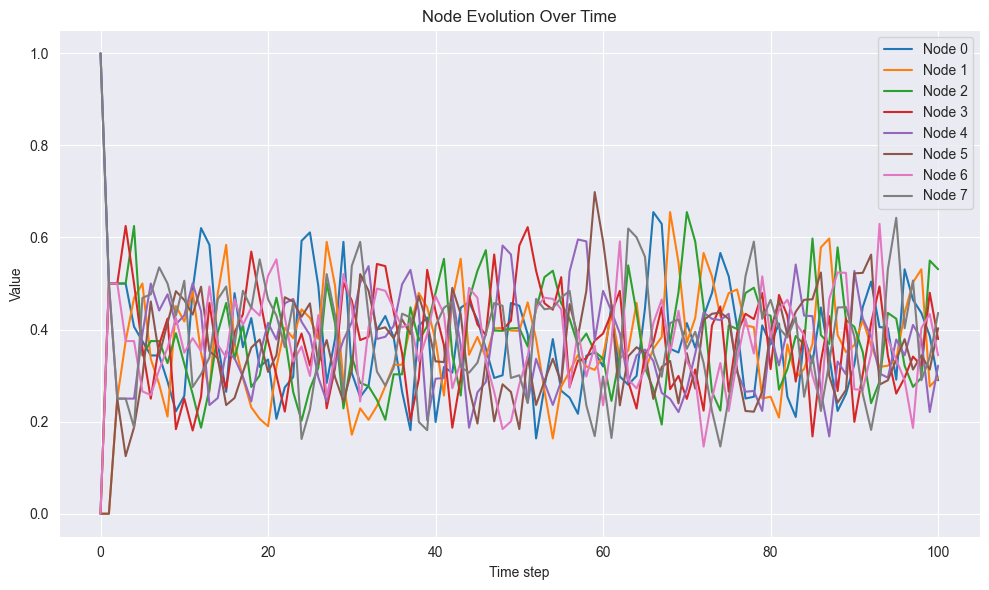

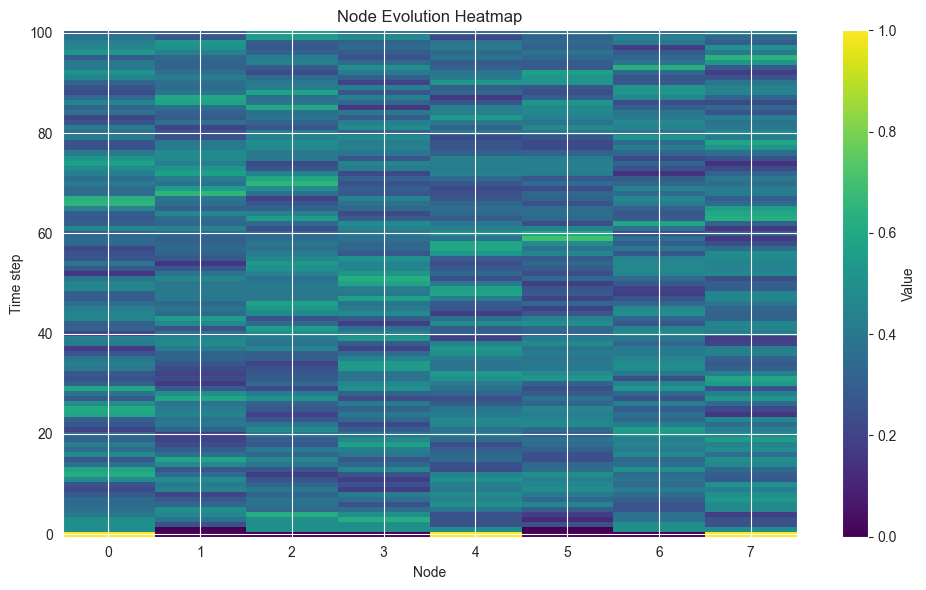

In [24]:
def plot_node_evolution(data):
    data = np.asarray(data)
    time_steps, num_nodes = data.shape

    # Line plot: evolution of each node
    plt.figure(figsize=(10, 6))
    for i in range(num_nodes):
        plt.plot(range(time_steps), data[:, i], label=f'Node {i}')
    plt.xlabel('Time step')
    plt.ylabel('Value')
    plt.title('Node Evolution Over Time')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Heatmap: time vs node
    plt.figure(figsize=(10, 6))
    plt.imshow(data, aspect='auto', cmap='viridis', origin='lower')
    plt.colorbar(label='Value')
    plt.xlabel('Node')
    plt.ylabel('Time step')
    plt.title('Node Evolution Heatmap')
    plt.tight_layout()
    plt.show()
plot_node_evolution(pops_NM_c2[8])